In [1]:
!pip install evaluate
!pip install datasets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 2.9 MB/s eta 0:00:00


In [2]:
!pip install protobuf==3.20.3

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.1/162.1 kB 4.7 MB/s eta 0:00:00
  Attempting uninstall: protobuf
    Found existing installation: protobuf 5.29.5
    Uninstalling protobuf-5.29.5:
      Successfully uninstalled protobuf-5.29.5
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.26.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
grain 0.2.15 requires protobuf>=5.28.3, but you have protobuf 3.20.3 which is incompatible.
onnx 1.20.0 requires protobuf>=4.25.1, but you have protobuf 3.20.3 which is incompatible.
ray 2.52.1 requires click!=8.3.*,>=7.0, but you have click 8.3.1 which is incompatible.
opentelemetry-proto 1.37.0 requires protobuf<7.0,>=5.0, but you have protobuf 3.20.3 which is incompatible.
tensorflow-metadata 1.17.2 requires protobuf>=4.25.2; python_version >= "3.11", but you have protobuf 3.20.

In [3]:
import pandas as pd
import numpy as np
from datasets import Dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer, EarlyStoppingCallback
import evaluate

2026-01-04 15:29:25.763789: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1767540565.971822      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1767540566.037894      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1767540566.577311      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1767540566.577351      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1767540566.577354      55 computation_placer.cc:177] computation placer alr

In [4]:
import json
import pandas as pd
import re
with open('/kaggle/input/heart-data/dataset_V1.json', 'r') as file:
    data = json.load(file)

In [5]:
def preprocess_patient_data(data):
    data = data.strip()
    data = re.sub(r'\s+', ' ', data)
    data = re.sub(r'[-:;]', '', data)
    return data

data_list = []
for idx, entry in enumerate(data):
  cleaned_patient_data = preprocess_patient_data(entry['patient_data'])
  data_list.append({
      'id': idx + 1,
      'label': entry['label'],
      'patient_data': entry['patient_data']
  })

df = pd.DataFrame(data_list)
print(df)

      id     label                                       patient_data
0      1    Normal  Age : 70years; descriptions : - lv a cavity si...
1      2    Normal  Age : 45 years; measurements : - ivst mm - 35 ...
2      3    Normal  Age : 50years; descriptions : - lv a cavity si...
3      4    Normal  Age : 48 years; descriptions : - lv a cavity s...
4      5  moderate  Age : 65 years; descriptions : la - normal, rv...
..   ...       ...                                                ...
714  715  moderate  Age : 35 years; measurements : ivst mm - 46 lv...
715  716    Normal  Age : 24 years; descriptions : - lv a cavity s...
716  717    Normal  Age : 60 years; descriptions : - lv a cavity s...
717  718  moderate  Age : 60years; descriptions : - lv a cavity si...
718  719  moderate  Age : 73 years; measurements : ivst mm - 73 lv...

[719 rows x 3 columns]


In [6]:
df.to_csv('./dataset_V1.csv')

In [7]:
main_data = df
main_data.drop(index=0)

,id,label,patient_data
1,2,Normal,Age : 45 years; measurements : - ivst mm - 35 ...
2,3,Normal,Age : 50years; descriptions : - lv a cavity si...
3,4,Normal,Age : 48 years; descriptions : - lv a cavity s...
4,5,moderate,"Age : 65 years; descriptions : la - normal, rv..."
5,6,mild,Age : 65 years; descriptions : - lv a cavity s...
...,...,...,...
714,715,moderate,Age : 35 years; measurements : ivst mm - 46 lv...
715,716,Normal,Age : 24 years; descriptions : - lv a cavity s...
716,717,Normal,Age : 60 years; descriptions : - lv a cavity s...
717,718,moderate,Age : 60years; descriptions : - lv a cavity si...


In [8]:
percent = (main_data.isnull().sum() / main_data.shape[0]) * 100
new_train = pd.DataFrame(data=percent, columns=['Percentofnullvalues'])
new_train = new_train.sort_values(by='Percentofnullvalues', ascending=False)
print(new_train.head(15))

              Percentofnullvalues
id                            0.0
label                         0.0
patient_data                  0.0


In [9]:
main_data.isna().sum()

id              0
label           0
patient_data    0
dtype: int64

In [10]:
main_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 719 entries, 0 to 718
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   id            719 non-null    int64 
 1   label         719 non-null    object
 2   patient_data  719 non-null    object
dtypes: int64(1), object(2)
memory usage: 17.0+ KB


In [11]:
def remove_columns(data):
    ''' Computing percent of null values in a dataset based on the feature and removing those features having 70 or more than 70 percent of null values '''
    columns_to_be_removed = []
    percent = (data.isnull().sum()/data.shape[0]) * 100
    for col in data.columns:
        if percent.loc[col] >= 80:
            columns_to_be_removed.append(col)
    new_data = data.drop(columns=columns_to_be_removed)
    return new_data
main_data = remove_columns(main_data)


In [12]:
main_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 719 entries, 0 to 718
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   id            719 non-null    int64 
 1   label         719 non-null    object
 2   patient_data  719 non-null    object
dtypes: int64(1), object(2)
memory usage: 17.0+ KB


In [13]:
main_data = main_data.dropna()
main_data.head(10)

,id,label,patient_data
0,1,Normal,Age : 70years; descriptions : - lv a cavity si...
1,2,Normal,Age : 45 years; measurements : - ivst mm - 35 ...
2,3,Normal,Age : 50years; descriptions : - lv a cavity si...
3,4,Normal,Age : 48 years; descriptions : - lv a cavity s...
4,5,moderate,"Age : 65 years; descriptions : la - normal, rv..."
5,6,mild,Age : 65 years; descriptions : - lv a cavity s...
6,7,poor,Age : years; measurements : - ivst mm - na - l...
7,8,Normal,Age : 80years; descriptions : - lv a cavity si...
8,9,Normal,Age : 40years; descriptions : - lv a cavity si...
9,10,Normal,Age : 55years; descriptions : - lv a cavity si...


In [14]:
main_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 719 entries, 0 to 718
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   id            719 non-null    int64 
 1   label         719 non-null    object
 2   patient_data  719 non-null    object
dtypes: int64(1), object(2)
memory usage: 17.0+ KB


In [15]:
print("\nSummary Statistics:")
print(main_data.describe())


Summary Statistics:
               id
count  719.000000
mean   360.000000
std    207.701709
min      1.000000
25%    180.500000
50%    360.000000
75%    539.500000
max    719.000000


In [16]:
# 1. First, keep only the 4 categories you want
filtered_labels = ['Normal', 'mild', 'moderate', 'poor']
df = df[df['label'].isin(filtered_labels)].copy()

# 2. Now run your encoding logic
label_map = {label: idx for idx, label in enumerate(df['label'].unique())}
df['label'] = df['label'].map(label_map)

# 3. Verify - should now only show 4 classes
print(df['label'].value_counts())
print(label_map)

label
0    373
2    144
1    123
3     39
Name: count, dtype: int64
{'Normal': 0, 'moderate': 1, 'mild': 2, 'poor': 3}


In [17]:
import pandas as pd

# Load the dataset
df = pd.read_csv('./dataset_V1.csv')

# Filter the DataFrame to only include the specified labels
filtered_labels = ['Normal', 'mild', 'moderate', 'poor']
filtered_df = df[df['label'].isin(filtered_labels)]

# Print the value counts to verify
print(filtered_df['label'].value_counts())

# Save the filtered DataFrame back to a CSV file
filtered_df.to_csv('./filtered_dataset_V1.csv', index=False)


label
Normal      373
mild        144
moderate    123
poor         39
Name: count, dtype: int64


In [18]:
# Train-test split
train_data = filtered_df.sample(frac=0.8, random_state=42)
test_data = filtered_df.drop(train_data.index)

# Convert to Hugging Face Datasets
hg_train_data = Dataset.from_pandas(train_data)
hg_test_data = Dataset.from_pandas(test_data)

print(f'The length of train_data is {len(hg_train_data)}')
print(f'The length of test_data is {len(hg_test_data)}')


The length of train_data is 543
The length of test_data is 136


In [19]:
!pip install transformers -U

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 119.5 MB/s eta 0:00:0000:01:01
  Attempting uninstall: transformers
    Found existing installation: transformers 4.57.1
    Uninstalling transformers-4.57.1:
      Successfully uninstalled transformers-4.57.1


In [20]:
!pip install accelerate

In [21]:
import pandas as pd
from datasets import Dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer
import torch
import numpy as np
import evaluate
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Load the dataset
pd.read_csv('/kaggle/working/filtered_dataset_V1.csv')

# Combine text data into a single column if necessary
df['combined_text'] = df['patient_data']


In [22]:
import pandas as pd
from datasets import Dataset

# 1. Reload fresh data
df = pd.read_csv('./filtered_dataset_V1.csv')
df['combined_text'] = df['patient_data']

# 2. Force clean labels (removes spaces and fixes case)
df['label'] = df['label'].str.strip()

# 3. Filter strictly for your 4 target labels
target_labels = ['Normal', 'mild', 'moderate', 'poor']
df = df[df['label'].isin(target_labels)].copy()

# 4. Map to integers
label_map = {'Normal': 0, 'mild': 1, 'moderate': 2, 'poor': 3}
df['label'] = df['label'].map(label_map)

# 5. Split the data
train_data = df.sample(frac=0.8, random_state=42)
test_data = df.drop(train_data.index)

# 6. Convert to Hugging Face format
hg_train_data = Dataset.from_pandas(train_data)
hg_test_data = Dataset.from_pandas(test_data)

print(f'The length of train_data is {len(hg_train_data)}')
print(f'The length of test_data is {len(hg_test_data)}')

The length of train_data is 543
The length of test_data is 136


In [23]:
# # Save the preprocessed DataFrame back to a CSV file
# df.to_csv('/content/drive/MyDrive/disease_classification/processed_dataset_V1.csv', index=False)


In [24]:
# 1. Initialize Tokenizer
tokenizer = AutoTokenizer.from_pretrained("medicalai/ClinicalBERT")

# 2. Function to tokenize data
def tokenize_dataset(data):
    return tokenizer(data["combined_text"], truncation=True, padding="max_length", max_length=512)

# 3. Tokenize the imbalanced datasets (Using hg_train_data from Cell 24)
dataset_train = hg_train_data.map(tokenize_dataset, batched=True)
dataset_test = hg_test_data.map(tokenize_dataset, batched=True)

# 4. Load Model (Optimized for Kaggle T4 x2)
# We remove .to(device) here so the Trainer can handle Multi-GPU distribution
model = AutoModelForSequenceClassification.from_pretrained(
    "medicalai/ClinicalBERT",
    num_labels=len(label_map),
    ignore_mismatched_sizes=True
)

tokenizer_config.json:   0%|          | 0.00/62.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/466 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

Map:   0%|          | 0/543 [00:00<?, ? examples/s]

Map:   0%|          | 0/136 [00:00<?, ? examples/s]

pytorch_model.bin:   0%|          | 0.00/542M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/542M [00:00<?, ?B/s]

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at medicalai/ClinicalBERT and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [25]:
# Load model
# Load the model without forcing it to a specific device
model = AutoModelForSequenceClassification.from_pretrained(
    "medicalai/ClinicalBERT",
    num_labels=len(label_map),
    ignore_mismatched_sizes=True
)

# Set up training arguments
training_args = TrainingArguments(
    output_dir="./results",      # Changed for Kaggle
    logging_dir='./logs',        # Changed for Kaggle
    logging_strategy='epoch',
    logging_steps=10,
    num_train_epochs=100,
    per_device_train_batch_size=35,
    per_device_eval_batch_size=20,
    learning_rate=5e-6,
    seed=42,
    eval_strategy='epoch',
    eval_steps=100,
    report_to="none"
)

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at medicalai/ClinicalBERT and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [26]:
import evaluate
from scipy.special import softmax

# Function to compute metrics
def compute_metrics(eval_pred):
    metric = evaluate.load("accuracy")
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=1)
    return metric.compute(predictions=predictions, references=labels)

# Train the model
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=dataset_train,
    eval_dataset=dataset_test,
    compute_metrics=compute_metrics,
)

# Train the model
trainer.train()

# Evaluate the model
trainer.evaluate(dataset_test)



/usr/local/lib/python3.12/dist-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(


Epoch,Training Loss,Validation Loss,Accuracy
1,1.398800,1.357576,0.529412
2,1.334600,1.297795,0.529412
3,1.272000,1.243987,0.529412
4,1.223900,1.189370,0.529412
5,1.164500,1.138280,0.529412
6,1.112100,1.099393,0.529412
7,1.070300,1.049620,0.529412
8,1.013300,0.991347,0.529412
9,0.954300,0.937565,0.529412
10,0.917500,0.890560,0.529412


/usr/local/lib/python3.12/dist-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked t

{'eval_loss': 0.30377519130706787,
 'eval_accuracy': 0.9117647058823529,
 'eval_runtime': 1.804,
 'eval_samples_per_second': 75.386,
 'eval_steps_per_second': 2.217,
 'epoch': 100.0}

/usr/local/lib/python3.12/dist-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(



        Recall Score ----> 0.9117647058823529
        F1 Score --------> 0.9117647058823529



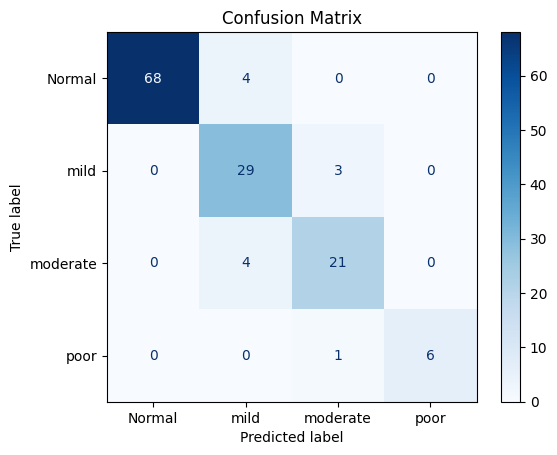

In [27]:
from scipy.special import softmax
y_test_predict = trainer.predict(dataset_test)
y_test_logits = y_test_predict.predictions
y_test_probabilities = softmax(y_test_logits, axis=1)
y_test_pred_labels = np.argmax(y_test_probabilities, axis=1)
y_test_actual_labels = y_test_predict.label_ids

metric_f1 = evaluate.load("f1")
f1_score = metric_f1.compute(predictions=y_test_pred_labels, references=y_test_actual_labels, average='micro')

metric_recall = evaluate.load("recall")
recall_score = metric_recall.compute(predictions=y_test_pred_labels, references=y_test_actual_labels, average='micro')

print(f"""
        Recall Score ----> {list(recall_score.values())[0]}
        F1 Score --------> {list(f1_score.values())[0]}
""")

# Plot confusion matrix
cm = confusion_matrix(y_test_actual_labels, y_test_pred_labels)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=list(label_map.keys()))
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.show()


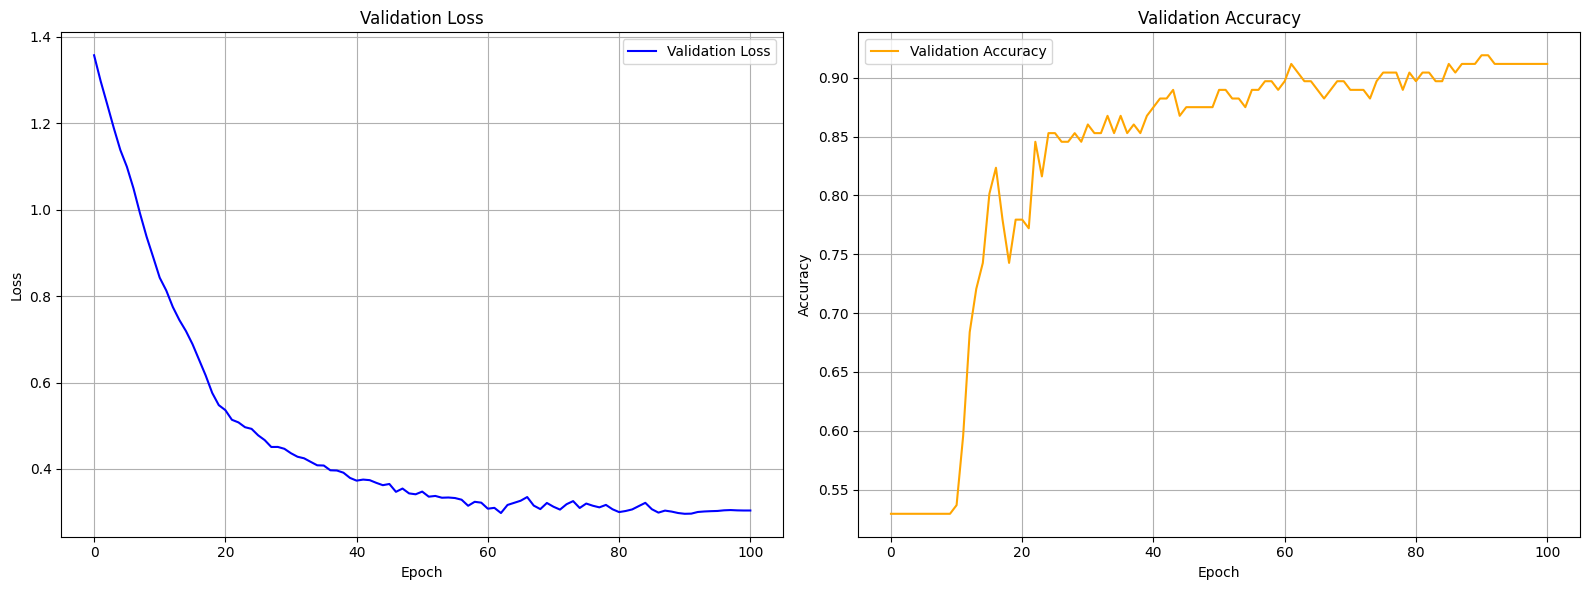

In [28]:
import matplotlib.pyplot as plt

# Extract validation metrics from trainer state
val_loss = [metrics.get('eval_loss') for metrics in trainer.state.log_history if 'eval_loss' in metrics]
val_acc = [metrics.get('eval_accuracy') for metrics in trainer.state.log_history if 'eval_accuracy' in metrics]

# Plot validation metrics
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Plot validation loss
ax1.plot(range(len(val_loss)), val_loss, label='Validation Loss', color='blue')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Validation Loss')
ax1.legend()
ax1.grid(True)

# Plot validation accuracy
ax2.plot(range(len(val_acc)), val_acc, label='Validation Accuracy', color='orange')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.set_title('Validation Accuracy')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()


In [29]:
# Use a local folder name or the Kaggle working directory
folder_name = "./analysis_u"

# Save the tokenizer and the model
tokenizer.save_pretrained(folder_name)
trainer.save_model(folder_name)

print(f"Model and tokenizer saved to: {folder_name}")


Model and tokenizer saved to: ./analysis_u


In [30]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch

# 1. Update Path: Change from /content/ to the local folder where you saved it
folder_name = "./analysis_u" 

# 2. Load tokenizer and model from the local folder
tokenizer = AutoTokenizer.from_pretrained(folder_name)
model = AutoModelForSequenceClassification.from_pretrained(folder_name)

# Input text for prediction
input_text = "Age : 70years; descriptions : - lv a cavity size - normal, - wall thickness - normal, - wall motion - normal, others - not mentioned in the text. ; color_flow_report : mitral valve - normal aortic valve - normal pulmonary valve - normal tricuspid valve - normal impression "

# 3. Tokenize (Make sure max_length matches your training: 512)
inputs = tokenizer(input_text, return_tensors="pt", truncation=True, padding=True, max_length=512)

# 4. Make predictions
model.eval() # Set model to evaluation mode
with torch.no_grad():
    outputs = model(**inputs)
    predicted_class = torch.argmax(outputs.logits, dim=1).item()

# 5. Label Map (Must match the one used in Cell 24)
label_map = {0: "Normal", 1: "mild", 2: "moderate", 3: "poor"}
predicted_label = label_map[predicted_class]

# Print predicted label
print(f"The predicted label of the text is: {predicted_label}")

The predicted label of the text is: Normal
